## Příprava dat- vše co je v porozumění datům + Příprava dat

In [1]:
# IMPORTY + CESTY
import pandas as pd
import numpy as np
import re
import os
import warnings

import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings("ignore", message="Workbook contains no default style*")
PATH_XLSX = "AMR_HourlyTransPerCashier.xlsx"
OUT_DIR = "priprava_dat"
os.makedirs(OUT_DIR, exist_ok=True)

# Výstupy — CSV
OUT_SHIFTS_TOTAL_CSV    = os.path.join(OUT_DIR, "shifts_total.csv")
OUT_SHIFTS_HUMANS_CSV   = os.path.join(OUT_DIR, "shifts_humans.csv")
OUT_SHIFTS_CHANNELS_CSV = os.path.join(OUT_DIR, "shifts_channels.csv")

# Výstupy — XLSX
OUT_SHIFTS_TOTAL_XLSX    = os.path.join(OUT_DIR, "shifts_total.xlsx")
OUT_SHIFTS_HUMANS_XLSX   = os.path.join(OUT_DIR, "shifts_humans.xlsx")
OUT_SHIFTS_CHANNELS_XLSX = os.path.join(OUT_DIR, "shifts_channels.xlsx")

# Výstupy — anomálie
OUT_ANOMALIES_CSV  = os.path.join(OUT_DIR, "anomalies_final.csv")
OUT_ANOMALIES_XLSX = os.path.join(OUT_DIR, "anomalies_final.xlsx")

# --- nastavení kdy končí a začínají noční směny
NIGHT_START_FROM = 18
NIGHT_END_UNTIL  = 10
MAX_HUMAN_HOURS  = 12
GAP_TOLERANCE    = 1

MIDNIGHT_LATE_HOURS  = [21, 22, 23]
MIDNIGHT_EARLY_HOURS = [0, 1, 2]


# funkce, která převádí sos do správného formátu
def parse_sos_to_seconds(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    parts = s.split(":")
    try:
        if len(parts) == 2:
            m, sec = map(int, parts)
            return m * 60 + sec
        if len(parts) == 3:
            h, m, sec = map(int, parts)
            return h * 3600 + m * 60 + sec
    except ValueError:
        return np.nan
    return np.nan

# funkce, která převádí agc do správného formátu
def to_float_agc(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.number)):
        return float(x)
    s = str(x).strip().replace(" ", "").replace(",", ".")
    try:
        return float(s)
    except ValueError:
        return np.nan


def detect_hour_cols(df):
    names = {str(c).strip(): c for c in df.columns}
    if all(f"{i:02d}" in names for i in range(24)):
        return [names[f"{i:02d}"] for i in range(24)]
    return list(df.columns[1:25])


def pick_col(df, keywords):
    for c in df.columns:
        c_norm = str(c).lower()
        if any(k in c_norm for k in keywords):
            return c
    return None


# --- infer směny (pokladní)
def infer_best_shift_from_hourly_humans(row, hour_cols, date):
    vals = []
    for h in hour_cols:
        v = row[h]
        if pd.isna(v):
            v = 0
        try:
            v = float(v)
        except Exception:
            v = 0
        vals.append(v)

    active = [i for i, v in enumerate(vals) if v > 0]
    if not active:
        return pd.NaT, pd.NaT, np.nan, np.nan

    blocks, cur = [], [active[0]]
    for h in active[1:]:
        if h <= cur[-1] + 1 + GAP_TOLERANCE:
            cur.append(h)
        else:
            blocks.append(cur)
            cur = [h]
    blocks.append(cur)

    best_sum, best_len, best_hours = -1, None, None
    for b in blocks:
        hours = list(range(min(b), max(b) + 1))
        s = sum(vals[h] for h in hours)
        if s > best_sum:
            best_sum, best_len, best_hours = s, len(hours), hours

    day0 = pd.to_datetime(date).normalize()
    start = day0 + pd.to_timedelta(best_hours[0], "h")
    end   = day0 + pd.to_timedelta(best_hours[-1] + 1, "h")
    tph = best_sum / best_len if best_len > 0 else np.nan

    return start, end, float(best_len), tph


# z xlsx souboru získá data do správné podoby
def prepare_shifts_from_excel(path_xlsx):
    df = pd.read_excel(path_xlsx, sheet_name="Report")

    hour_cols = detect_hour_cols(df)
    total_col = pick_col(df, ["total"]) or df.columns[25]
    sos_col   = pick_col(df, ["sos"])   or df.columns[26]
    agc_col   = pick_col(df, ["agc"])   or df.columns[27]

    records = []
    current_date = None
    date_re = re.compile(r"^\d{4}-\d{2}-\d{2}$")

    for _, row in df.iterrows():
        first = row.iloc[0]

        if isinstance(first, str) and first.strip().upper() == "ALL DAYS TOTAL":
            current_date = None
            continue

        if isinstance(first, pd.Timestamp):
            current_date = pd.to_datetime(first).normalize()
            continue
        if isinstance(first, str) and date_re.match(first.strip()):
            current_date = pd.to_datetime(first.strip()).normalize()
            continue

        if current_date is None or not isinstance(first, str):
            continue

        name = first.strip()
        name_u = name.upper()

        if name == "" or name_u in {"EMPLOYEES/HOURS", "TOTAL"}:
            continue
        if "TOTAL" in name_u:
            continue

        start, end, dur, tph = infer_best_shift_from_hourly_humans(
            row, hour_cols, current_date
        )

        # pocet transakci za smenu = TPH * delka smeny
        pocet_trans = tph * float(dur) if (pd.notna(tph) and pd.notna(dur)) else np.nan

        records.append({
            "datum": current_date,
            "zamestnanec": name,
            "pocet_transakci": pocet_trans,
            "transakce_za_hod": tph,
            "SOS_sec": parse_sos_to_seconds(row[sos_col]),
            "AGC": to_float_agc(row[agc_col]),
            "smena_zacatek": start,
            "smena_konec": end,
            "trvani_hodin": dur,
            "_total_day": row[total_col]
        })

    return pd.DataFrame(records)



shifts_raw = prepare_shifts_from_excel(PATH_XLSX)

required = ["transakce_za_hod", "SOS_sec", "AGC", "trvani_hodin", "pocet_transakci"]
n_before = len(shifts_raw)

# odstrani zaporne agc
shifts_all = shifts_raw.dropna(subset=required).copy()
n_after_na = len(shifts_all)

# vytvoření ID směny
shifts_all["ID"] = shifts_all.index

bad_mask = (
    (shifts_all["AGC"] < 0) |
    (shifts_all["SOS_sec"] <= 0) |
    (shifts_all["trvani_hodin"] <= 0) |
    (shifts_all["transakce_za_hod"] <= 0) |
    (shifts_all["pocet_transakci"] <= 0)
)

bad_shifts = shifts_all[bad_mask].copy()
shifts_clean = shifts_all[~bad_mask].copy()

n_after_real = len(shifts_clean)
# FILTR: MIN POCET TRANSAKCI >= 10
n_before_cnt = len(shifts_clean)
shifts_clean = shifts_clean[shifts_clean["pocet_transakci"] >= 10].copy()
n_after_cnt = len(shifts_clean)

# FILTR: MINIMÁLNÍ AGC 50
n_before_agc = len(shifts_clean)
shifts_clean = shifts_clean[shifts_clean["AGC"] >= 50].copy()
n_after_agc = len(shifts_clean)

print(" ČIŠTĚNÍ (shrnutí)")
print(f"Počáteční záznamy: {n_before}")
print(f"Po dropna (required): {n_after_na}  (odstraněno {n_before - n_after_na})")
print(f"Vyčištěná data (bez nereálných): {n_after_real}  (odstraněno {n_after_na - n_after_real})")
print(f"Min transakci filtr (>=10): {n_after_cnt}  (odstraněno {n_before_cnt - n_after_cnt})")
print(f"AGC filtr (>=50): {n_after_agc}  (odstraněno {n_before_agc - n_after_agc})")


#rozdeli smeny na lidi a delivery + kiosky
def split_humans_vs_channels(df):
    pat = r"(?:BOLT|WOLT|DELIVERY|HERO|KIOSK|API)"
    mask = df["zamestnanec"].str.contains(pat, case=False, regex=True, na=False)
    return df[~mask].copy(), df[mask].copy()


def force_channels_full_day(df):
    df = df.copy()
    day0 = pd.to_datetime(df["datum"]).dt.normalize()
    df["smena_zacatek"] = day0
    df["smena_konec"] = day0 + pd.Timedelta(days=1)
    df["trvani_hodin"] = 24.0
    df["transakce_za_hod"] = pd.to_numeric(df["_total_day"], errors="coerce") / 24.0
    df["pocet_transakci"] = pd.to_numeric(df["_total_day"], errors="coerce")
    return df

# anonymizuje zamestnance

def anonymize_employees(df):
    mapping = {n: f"#{i+1}" for i, n in enumerate(sorted(df["zamestnanec"].unique()))}
    df = df.copy()
    df["zamestnanec"] = df["zamestnanec"].map(mapping)
    return df, mapping


shifts_humans, shifts_channels = split_humans_vs_channels(shifts_clean)
shifts_channels = force_channels_full_day(shifts_channels)
shifts_humans, anon_map = anonymize_employees(shifts_humans)

# Logaritmicka transformace trans/h + agc
shifts_humans["log_transakce_za_hod"] = np.log1p(shifts_humans["transakce_za_hod"])
shifts_humans["log_agc"] = np.log1p(shifts_humans["AGC"])


shifts_humans_all, shifts_channels_all = split_humans_vs_channels(shifts_all)
shifts_channels_all = force_channels_full_day(shifts_channels_all)
shifts_humans_all, _ = anonymize_employees(shifts_humans_all)

shifts_total = pd.concat([shifts_humans_all, shifts_channels_all], ignore_index=True)

# anonymizace i u nereálných směn
if len(bad_shifts) > 0:
    bad_shifts = bad_shifts.copy()
    bad_shifts["zamestnanec"] = bad_shifts["zamestnanec"].map(lambda x: anon_map.get(x, x))

    bad_shifts["duvod"] = ""
    bad_shifts.loc[bad_shifts["AGC"] < 0, "duvod"] += "AGC<0; "
    bad_shifts.loc[bad_shifts["SOS_sec"] <= 0, "duvod"] += "SOS<=0; "
    bad_shifts.loc[bad_shifts["trvani_hodin"] <= 0, "duvod"] += "trvani<=0; "
    bad_shifts.loc[bad_shifts["transakce_za_hod"] <= 0, "duvod"] += "TPH<=0; "
    bad_shifts.loc[bad_shifts["pocet_transakci"] <= 0, "duvod"] += "pocet_transakci<=0; "
    bad_shifts["duvod"] = bad_shifts["duvod"].str.strip()

# pomocný sloupec pryč
for df_ in (shifts_total, shifts_humans, shifts_channels, bad_shifts):
    df_.drop(columns=["_total_day"], inplace=True, errors="ignore")


# vypisy jak jsou dlouhe jednotlive datasety
from IPython.display import display

def safe_cols(df, cols):
    return [c for c in cols if c in df.columns]

# vytvoření unikátního klíče směny
for df_ in (shifts_total, shifts_humans, shifts_channels):
    df_["shift_key"] = (
        df_["datum"].astype(str)
        + "_"
        + df_["zamestnanec"].astype(str)
        + "_"
        + df_["smena_zacatek"].astype(str)
    )

# vytvoření mapy ID
all_keys = pd.concat([
    shifts_total["shift_key"],
    shifts_humans["shift_key"],
    shifts_channels["shift_key"]
]).unique()

shift_map = {k: i+1 for i, k in enumerate(sorted(all_keys))}
def pridej_id(df):
    df["ID"] = df["shift_key"].map(shift_map)
    df.drop(columns=["shift_key"], inplace=True)

    cols = list(df.columns)
    cols.insert(1, cols.pop(cols.index("ID")))

    return df[cols]

shifts_total = pridej_id(shifts_total)
shifts_humans = pridej_id(shifts_humans)
shifts_channels = pridej_id(shifts_channels)
print("\n KONTROLA ČIŠTĚNÍ DAT")
print(f"Celkem záznamů (shifts_total, auditní – vše): {len(shifts_total)}")
print(f"Z toho zaměstnanci (shifts_humans, vyčištěné): {len(shifts_humans)}")
print(f"Z toho prodejní kanály (shifts_channels, vyčištěné): {len(shifts_channels)}")

# mix ukázka (zam + kanály) v shifts_total
print("\ Ukázka dat (shifts_total) — mix (zam + kanály):")
pattern = r"(?:BOLT|WOLT|DELIVERY|HERO|KIOSK|API)"
tmp = shifts_total.copy()
tmp["typ"] = np.where(
    tmp["zamestnanec"].str.contains(pattern, case=False, regex=True, na=False),
    "kanal",
    "zamestnanec"
)
ukazka = pd.concat([
    tmp[tmp["typ"] == "zamestnanec"].head(3),
    tmp[tmp["typ"] == "kanal"].head(3)
])
display(
    ukazka.drop(columns=["typ"])[
        ["datum", "ID", "zamestnanec", "pocet_transakci", "transakce_za_hod",
         "SOS_sec", "AGC", "smena_zacatek", "smena_konec", "trvani_hodin"]
    ]
)

print("\n Ukázka dat (shifts_humans) — head(5):")
display(
    shifts_humans[
        ["datum","ID", "zamestnanec", "pocet_transakci", "transakce_za_hod",
         "log_transakce_za_hod",
         "SOS_sec", "AGC", "log_agc",
         "smena_zacatek", "smena_konec", "trvani_hodin"]
    ].head(5)
)

print("\n Ukázka dat (shifts_channels) — head(5):")
display(
    shifts_channels[
        ["datum","ID", "zamestnanec", "pocet_transakci", "transakce_za_hod",
         "SOS_sec", "AGC", "smena_zacatek", "smena_konec", "trvani_hodin"]
    ].head(5)
)

print("\n Top 10 nejdelších směn (humans):")
display(
    shifts_humans
    .sort_values("trvani_hodin", ascending=False)[
        ["datum", "zamestnanec", "smena_zacatek", "smena_konec", "trvani_hodin",
         "pocet_transakci", "transakce_za_hod"]
    ]
    .head(10)
)

print("\nTop 10 nejvytíženějších směn (humans) — transakce za hodinu:")
display(
    shifts_humans
    .sort_values("transakce_za_hod", ascending=False)[
        ["datum", "zamestnanec", "trvani_hodin", "pocet_transakci",
         "transakce_za_hod", "AGC", "SOS_sec"]
    ]
    .head(10)
)

print("\nSměny se záporným AGC (audit – anonymizované):")
if len(bad_shifts) == 0:
    print("Žádné záporné AGC.")
else:
    display(
        bad_shifts[bad_shifts["AGC"] < 0][
            ["datum", "ID", "zamestnanec", "pocet_transakci", "transakce_za_hod",
             "SOS_sec", "AGC", "trvani_hodin",
             "smena_zacatek", "smena_konec", "duvod"]
        ]
        .sort_values("AGC")
    )
total_sum = pd.to_numeric(shifts_total["pocet_transakci"], errors="coerce").sum()
print("Součet pocet_transakci v shifts_total:", round(total_sum, 2))

# rozsah dat

num_cols = [
    "transakce_za_hod",
    "SOS_sec",
    "AGC",
    "trvani_hodin"
]

summary_range = (
    shifts_humans[num_cols]
    .agg(["min", "max"])
    .T
    .reset_index()
    .rename(columns={"index": "Atribut", "min": "Minimum", "max": "Maximum"})
)

summary_range


shifts_total.to_csv(OUT_SHIFTS_TOTAL_CSV, index=False, encoding="utf-8")
shifts_humans.to_csv(OUT_SHIFTS_HUMANS_CSV, index=False, encoding="utf-8")
shifts_channels.to_csv(OUT_SHIFTS_CHANNELS_CSV, index=False, encoding="utf-8")

shifts_total.to_excel(OUT_SHIFTS_TOTAL_XLSX, index=False)
shifts_humans.to_excel(OUT_SHIFTS_HUMANS_XLSX, index=False)
shifts_channels.to_excel(OUT_SHIFTS_CHANNELS_XLSX, index=False)

print("\nHotovo")

# statistické testy
import numpy as np
import pandas as pd
from scipy import stats

PATH_CHANNELS = OUT_SHIFTS_CHANNELS_CSV
PATH_HUMANS   = OUT_SHIFTS_HUMANS_CSV
# PATH_TOTAL záměrně nepoužíváme pro TEST 2 (kvůli konzistenci filtrů)


def clean_numeric(s):
    return pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().astype(float)


def cohen_d(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    nx, ny = len(x), len(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    s_pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2)/(nx+ny-2))
    return (np.mean(x) - np.mean(y)) / s_pooled


ch = pd.read_csv(PATH_CHANNELS)  
hu = pd.read_csv(PATH_HUMANS)   

df_all_clean = pd.concat([hu, ch], ignore_index=True)


# 1. statistický test AGC kiosek vs AGC zaměstnanec
ch["zamestnanec"] = ch["zamestnanec"].astype(str)
kiosk_mask = ch["zamestnanec"].str.contains("KIOSK", case=False, na=False)

kiosk_agc  = clean_numeric(ch.loc[kiosk_mask, "AGC"])
humans_agc = clean_numeric(hu["AGC"])

t1, p1_two = stats.ttest_ind(kiosk_agc, humans_agc, equal_var=False)  # Welch
p1_one = p1_two/2 if t1 > 0 else 1 - (p1_two/2)  # H1: kiosek > pokladna
d1 = cohen_d(kiosk_agc, humans_agc)

print("\n=== TEST 1: Kiosek vs Pokladna (AGC) ===")
print("Průměr Kiosek:", round(np.mean(kiosk_agc), 2))
print("Průměr Pokladna:", round(np.mean(humans_agc), 2))
print("t =", round(t1, 4))
print("p (2-stranně) =", f"{p1_two:.6g}")
print("p (1-stranně; kiosek > pokladna) =", f"{p1_one:.6g}")
print("Cohen d =", round(d1, 3))


# 2. statistický test Víkend vs Všední dny (odhad denních tržeb)
df = df_all_clean.copy()

df["datum"] = pd.to_datetime(df["datum"], errors="coerce")
df["AGC"] = pd.to_numeric(df["AGC"], errors="coerce")
df["pocet_transakci"] = pd.to_numeric(df["pocet_transakci"], errors="coerce")
df = df.dropna(
    subset=["datum", "AGC", "pocet_transakci"]).copy()

df["revenue_est"] = df["AGC"] * df["pocet_transakci"]

df["date"] = df["datum"].dt.date
daily = df.groupby("date", as_index=False)["revenue_est"].sum()

daily["datum"] = pd.to_datetime(daily["date"])
daily["dow"] = daily["datum"].dt.dayofweek
daily["is_weekend"] = daily["dow"].isin([5, 6])

weekend = daily.loc[daily["is_weekend"], "revenue_est"].values
weekday = daily.loc[~daily["is_weekend"], "revenue_est"].values

t2, p2_two = stats.ttest_ind(weekend, weekday, equal_var=False)  # Welch
p2_one = p2_two/2 if t2 > 0 else 1 - (p2_two/2)  # H1: víkend > všední
d2 = cohen_d(weekend, weekday)

print("\n=== TEST 2: Víkend vs Všední dny (denní tržby; vyčištěná data) ===")
print("Průměr víkend:", round(np.mean(weekend), 2))
print("Průměr všední:", round(np.mean(weekday), 2))
print("t =", round(t2, 4))
print("p (2-stranně) =", f"{p2_two:.6g}")
print("p (1-stranně; víkend > všední) =", f"{p2_one:.6g}")
print("Cohen d =", round(d2, 3))


# Korelace SOS vs AGC
xy = pd.DataFrame({
    "SOS": pd.to_numeric(hu["SOS_sec"], errors="coerce"),
    "AGC": pd.to_numeric(hu["AGC"], errors="coerce")
}).replace([np.inf, -np.inf], np.nan).dropna()

r, p3 = stats.pearsonr(xy["SOS"], xy["AGC"])
rho, p3s = stats.spearmanr(xy["SOS"], xy["AGC"])

print("\n=== TEST 3: Korelace SOS vs AGC (zaměstnanci) ===")
print("Pearson r =", round(r, 4))
print("p =", f"{p3:.6g}")
print("Spearman rho =", round(rho, 4))
print("p =", f"{p3s:.6g}")

 ČIŠTĚNÍ (shrnutí)
Počáteční záznamy: 5296
Po dropna (required): 3472  (odstraněno 1824)
Vyčištěná data (bez nereálných): 3461  (odstraněno 11)
Min transakci filtr (>=10): 2155  (odstraněno 1306)
AGC filtr (>=50): 2154  (odstraněno 1)

 KONTROLA ČIŠTĚNÍ DAT
Celkem záznamů (shifts_total, auditní – vše): 3472
Z toho zaměstnanci (shifts_humans, vyčištěné): 1342
Z toho prodejní kanály (shifts_channels, vyčištěné): 812
\ Ukázka dat (shifts_total) — mix (zam + kanály):


,datum,ID,zamestnanec,pocet_transakci,transakce_za_hod,SOS_sec,AGC,smena_zacatek,smena_konec,trvani_hodin
0,2025-01-01,2,#1,93.0,13.285714,38.0,173.92,2025-01-01 15:00:00,2025-01-01 22:00:00,7.0
1,2025-01-01,6,#7,34.0,17.000000,22.0,157.05,2025-01-01 22:00:00,2025-01-02 00:00:00,2.0
2,2025-01-01,1,#11,3.0,0.750000,4.0,108.44,2025-01-01 15:00:00,2025-01-01 19:00:00,4.0
2015,2025-01-01,8,BOLT BOLT,43.0,1.791667,503.0,458.37,2025-01-01 00:00:00,2025-01-02 00:00:00,24.0
2016,2025-01-01,9,DELIVERY_HERO DELIVERY,15.0,0.625000,263.0,372.86,2025-01-01 00:00:00,2025-01-02 00:00:00,24.0
2017,2025-01-01,11,KIOSKAPI1 API,887.0,36.958333,17.0,329.68,2025-01-01 00:00:00,2025-01-02 00:00:00,24.0



 Ukázka dat (shifts_humans) — head(5):


,datum,ID,zamestnanec,pocet_transakci,transakce_za_hod,log_transakce_za_hod,SOS_sec,AGC,log_agc,smena_zacatek,smena_konec,trvani_hodin
0,2025-01-01,2,#1,93.0,13.285714,2.659260,38.0,173.92,5.164329,2025-01-01 15:00:00,2025-01-01 22:00:00,7.0
3,2025-01-01,6,#7,34.0,17.000000,2.890372,22.0,157.05,5.062911,2025-01-01 22:00:00,2025-01-02 00:00:00,2.0
6,2025-01-01,3,#21,34.0,4.857143,1.767662,41.0,198.08,5.293707,2025-01-01 08:00:00,2025-01-01 15:00:00,7.0
7,2025-01-01,4,#23,52.0,10.400000,2.433613,30.0,214.72,5.373981,2025-01-01 03:00:00,2025-01-01 08:00:00,5.0
15,2025-01-02,17,#2,35.0,5.000000,1.791759,28.0,129.60,4.872139,2025-01-02 15:00:00,2025-01-02 22:00:00,7.0



 Ukázka dat (shifts_channels) — head(5):


...


Top 10 nejvytíženějších směn (humans) — transakce za hodinu:


,datum,zamestnanec,trvani_hodin,pocet_transakci,transakce_za_hod,AGC,SOS_sec
5290,2025-12-31,#25,2.0,39.0,19.500000,214.69,46.0
3,2025-01-01,#7,2.0,34.0,17.000000,157.05,22.0
3400,2025-08-16,#23,2.0,29.0,14.500000,157.67,26.0
673,2025-02-14,#3,2.0,29.0,14.500000,139.05,39.0
4848,2025-11-29,#23,6.0,81.0,13.500000,226.49,26.0
1106,2025-03-14,#3,2.0,27.0,13.500000,185.96,31.0
5026,2025-12-12,#23,3.0,40.0,13.333333,264.53,28.0
0,2025-01-01,#1,7.0,93.0,13.285714,173.92,38.0
1010,2025-03-07,#29,6.0,79.0,13.166667,156.65,30.0
1699,2025-04-22,#2,1.0,13.0,13.000000,104.63,25.0



Směny se záporným AGC (audit – anonymizované):


,datum,ID,zamestnanec,pocet_transakci,transakce_za_hod,SOS_sec,AGC,trvani_hodin,smena_zacatek,smena_konec,duvod
2013,2025-05-12,2013,#25,1.0,1.000000,44.0,-291.07,1.0,2025-05-12 23:00:00,2025-05-13 00:00:00,AGC<0;
3619,2025-09-01,3619,#7,2.0,1.000000,43.0,-280.66,2.0,2025-09-01 13:00:00,2025-09-01 15:00:00,AGC<0;
5021,2025-12-12,5021,#7,1.0,1.000000,5.0,-108.93,1.0,2025-12-12 20:00:00,2025-12-12 21:00:00,AGC<0;
3228,2025-08-04,3228,#11,1.0,1.000000,16.0,-107.14,1.0,2025-08-04 21:00:00,2025-08-04 22:00:00,AGC<0;
3158,2025-07-30,3158,#6,1.0,1.000000,53.0,-107.14,1.0,2025-07-30 21:00:00,2025-07-30 22:00:00,AGC<0;
4654,2025-11-15,4654,#9,2.0,2.000000,7.0,-104.91,1.0,2025-11-15 19:00:00,2025-11-15 20:00:00,AGC<0;
4996,2025-12-10,4996,#17,1.0,1.000000,6.0,-87.50,1.0,2025-12-10 17:00:00,2025-12-10 18:00:00,AGC<0;
1451,2025-04-05,1451,#9,5.0,1.666667,60.0,-70.14,3.0,2025-04-05 03:00:00,2025-04-05 06:00:00,AGC<0;
2586,2025-06-20,2586,#22,1.0,1.000000,38.0,-66.96,1.0,2025-06-20 01:00:00,2025-06-20 02:00:00,AGC<0;
3456,2025-08-20,3456,#7,1.0,1.000000,2.0,-15.18,1.0,2025-08-20 21:00:00,2025-08-20 22:00:00,AGC<0;


Součet pocet_transakci v shifts_total: 273940.0

Hotovo

=== TEST 1: Kiosek vs Pokladna (AGC) ===
Průměr Kiosek: 246.32
Průměr Pokladna: 161.78
t = 55.7997
p (2-stranně) = 2.00986e-320
p (1-stranně; kiosek > pokladna) = 1.00493e-320
Cohen d = 2.397

=== TEST 2: Víkend vs Všední dny (denní tržby; vyčištěná data) ===
Průměr víkend: 197574.01
Průměr všední: 165941.99
t = 7.351
p (2-stranně) = 5.52197e-12
p (1-stranně; víkend > všední) = 2.76098e-12
Cohen d = 0.847

=== TEST 3: Korelace SOS vs AGC (zaměstnanci) ===
Pearson r = 0.4089
p = 3.04278e-55
Spearman rho = 0.4657
p = 3.35535e-73


In [2]:
cols = [
    "datum",
    "zamestnanec",
     "ID",
    "pocet_transakci",
    "transakce_za_hod",
    "SOS_sec",
    "AGC",
    "smena_zacatek",
    "smena_konec",
    "trvani_hodin"
]

vypis = shifts_humans[cols]
display(vypis)

,datum,zamestnanec,ID,pocet_transakci,transakce_za_hod,SOS_sec,AGC,smena_zacatek,smena_konec,trvani_hodin
0,2025-01-01,#1,2,93.0,13.285714,38.0,173.92,2025-01-01 15:00:00,2025-01-01 22:00:00,7.0
3,2025-01-01,#7,6,34.0,17.000000,22.0,157.05,2025-01-01 22:00:00,2025-01-02 00:00:00,2.0
6,2025-01-01,#21,3,34.0,4.857143,41.0,198.08,2025-01-01 08:00:00,2025-01-01 15:00:00,7.0
7,2025-01-01,#23,4,52.0,10.400000,30.0,214.72,2025-01-01 03:00:00,2025-01-01 08:00:00,5.0
15,2025-01-02,#2,17,35.0,5.000000,28.0,129.60,2025-01-02 15:00:00,2025-01-02 22:00:00,7.0
...,...,...,...,...,...,...,...,...,...,...
5276,2025-12-30,#23,4267,25.0,6.250000,28.0,307.53,2025-12-30 00:00:00,2025-12-30 04:00:00,4.0
5285,2025-12-31,#4,4278,102.0,12.750000,37.0,172.80,2025-12-31 15:00:00,2025-12-31 23:00:00,8.0
5288,2025-12-31,#21,4274,42.0,6.000000,37.0,167.57,2025-12-31 08:00:00,2025-12-31 15:00:00,7.0
5289,2025-12-31,#23,4275,31.0,7.750000,27.0,150.76,2025-12-31 03:00:00,2025-12-31 07:00:00,4.0


## HISTOGRAMY


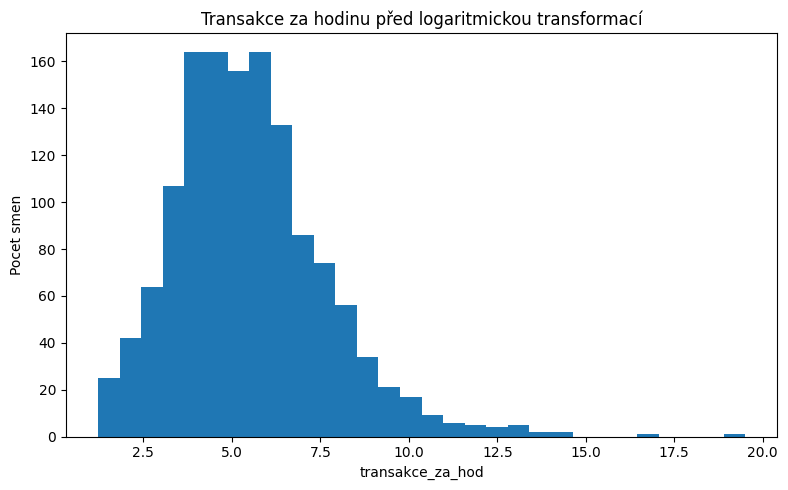

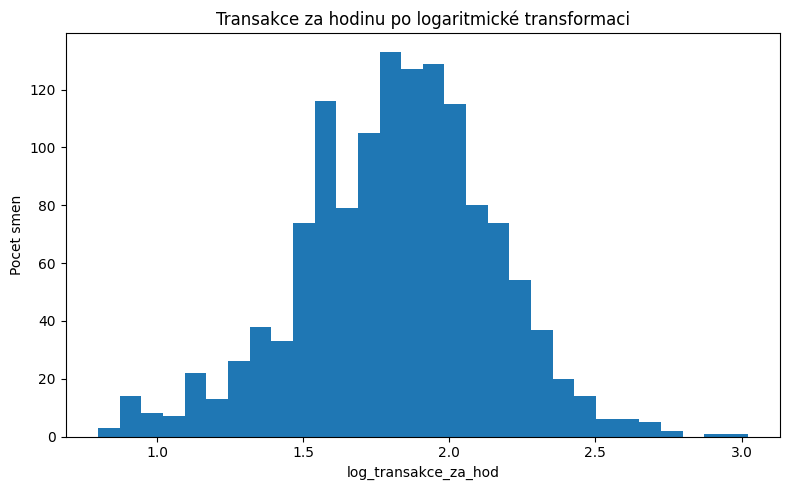

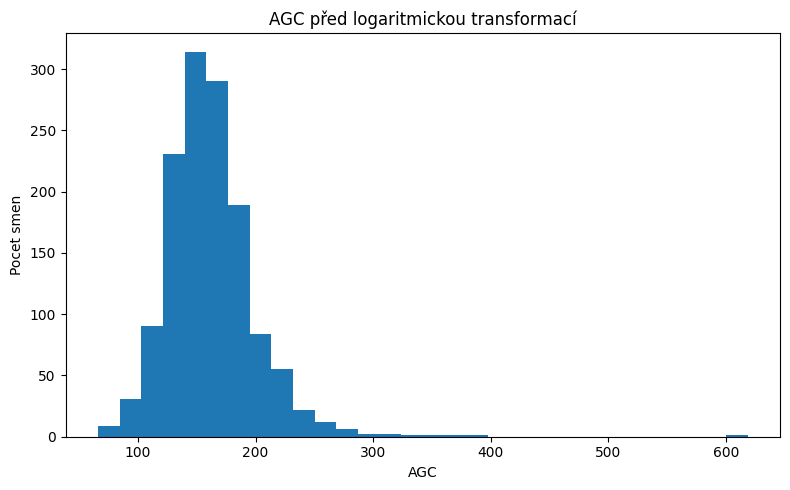

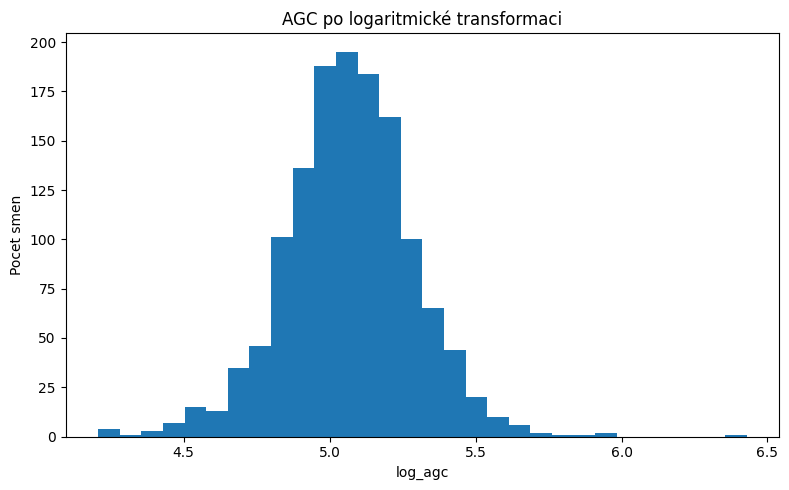

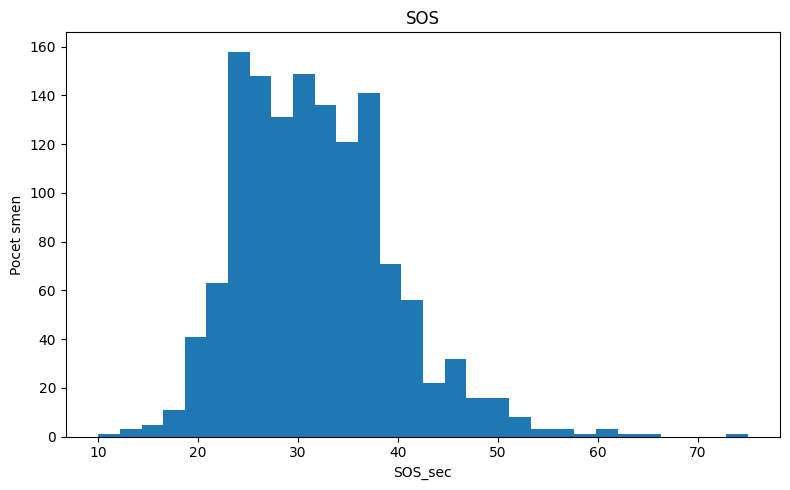

Histogramy byly ulozeny do složky 'histogramy':
 - histogramy/hist_transakce_za_hodinu_before.png
 - histogramy/hist_transakce_za_hodinu_after_log.png
 - histogramy/hist_agc_before.png
 - histogramy/hist_agc_after_log.png
 - histogramy/hist_sos_seconds_before.png


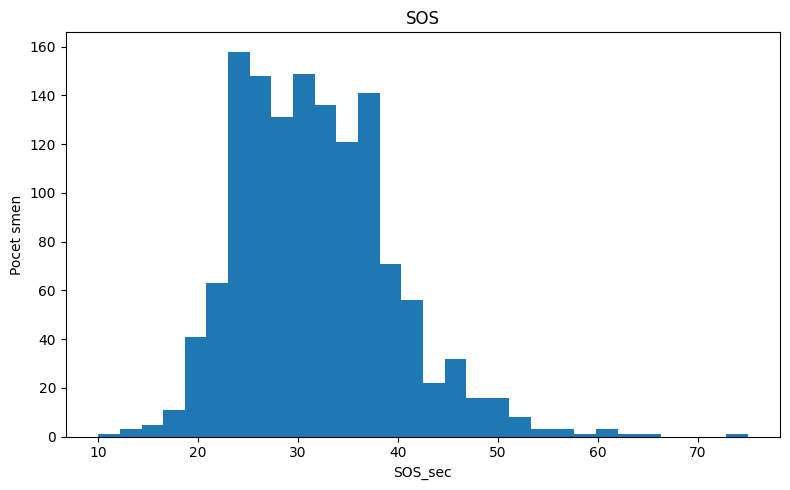

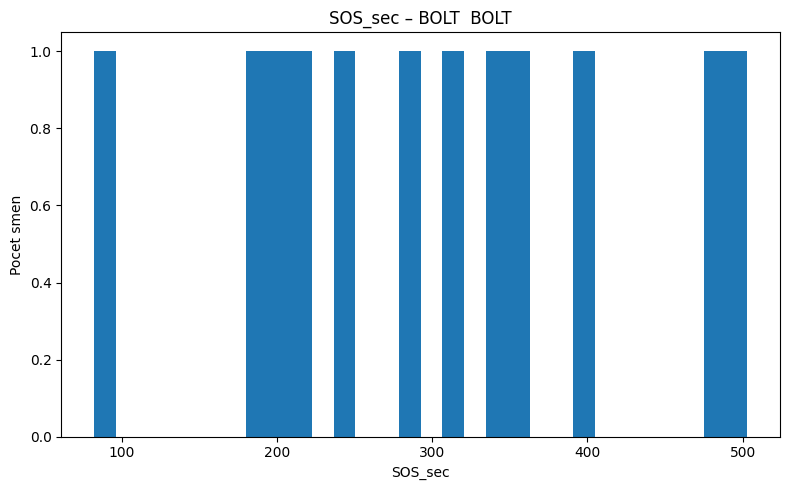

 - histogramy/hist_sos_bolt  bolt.png


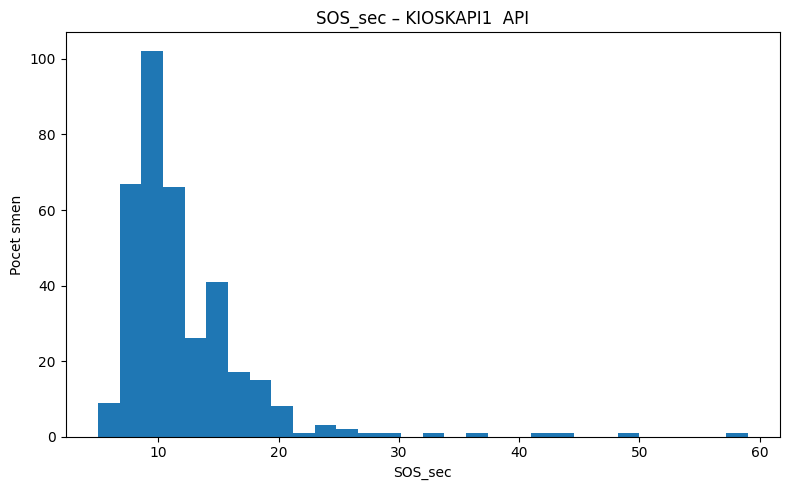

 - histogramy/hist_sos_kioskapi1  api.png


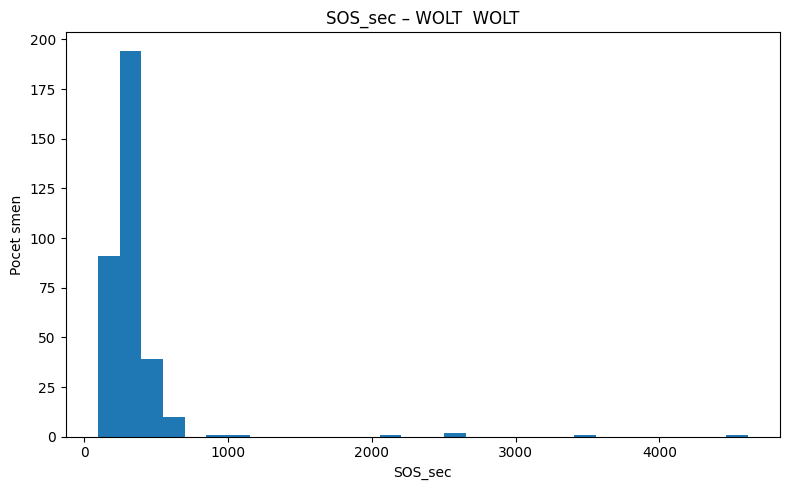

 - histogramy/hist_sos_wolt  wolt.png


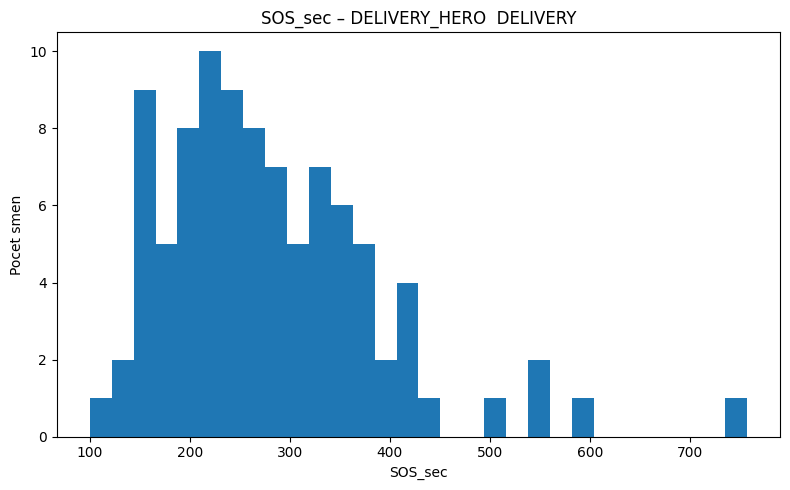

 - histogramy/hist_sos_delivery_hero  delivery.png


In [3]:


import os
import matplotlib.pyplot as plt

HIST_DIR = "histogramy"
os.makedirs(HIST_DIR, exist_ok=True)

# --- cesty pro ukládání histogramů
HIST_TPH_BEFORE = os.path.join(HIST_DIR, "hist_transakce_za_hodinu_before.png")
HIST_TPH_AFTER  = os.path.join(HIST_DIR, "hist_transakce_za_hodinu_after_log.png")

HIST_AGC_BEFORE = os.path.join(HIST_DIR, "hist_agc_before.png")
HIST_AGC_AFTER  = os.path.join(HIST_DIR, "hist_agc_after_log.png")

HIST_SOS_BEFORE = os.path.join(HIST_DIR, "hist_sos_seconds_before.png")


def save_hist(series, title, xlabel, out_path, bins=30):
    plt.figure(figsize=(8, 5))
    plt.hist(series.dropna(), bins=bins)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Pocet smen")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()



# Transakce za hodinu histogram
save_hist(
    shifts_humans["transakce_za_hod"],
    "Transakce za hodinu před logaritmickou transformací",
    "transakce_za_hod",
    HIST_TPH_BEFORE
)

save_hist(
    shifts_humans["log_transakce_za_hod"],
    "Transakce za hodinu po logaritmické transformaci",
    "log_transakce_za_hod",
    HIST_TPH_AFTER
)



# AGC histogram
save_hist(
    shifts_humans["AGC"],
    "AGC před logaritmickou transformací",
    "AGC",
    HIST_AGC_BEFORE
)

save_hist(
    shifts_humans["log_agc"],
    "AGC po logaritmické transformaci",
    "log_agc",
    HIST_AGC_AFTER
)



# SOS histogram
save_hist(
    shifts_humans["SOS_sec"],
    "SOS",
    "SOS_sec",
    HIST_SOS_BEFORE
)


print("Histogramy byly ulozeny do složky 'histogramy':")
print(" -", HIST_TPH_BEFORE)
print(" -", HIST_TPH_AFTER)
print(" -", HIST_AGC_BEFORE)
print(" -", HIST_AGC_AFTER)
print(" -", HIST_SOS_BEFORE)
# SOS (humans)
save_hist(
    shifts_humans["SOS_sec"],
    "SOS",
    "SOS_sec",
    HIST_SOS_BEFORE
)


for ch in shifts_channels["zamestnanec"].unique():

    data = shifts_channels[shifts_channels["zamestnanec"] == ch]["SOS_sec"]

    hist_path = os.path.join(HIST_DIR, f"hist_sos_{ch.lower()}.png")

    save_hist(
        data,
        f"SOS_sec – {ch}",
        "SOS_sec",
        hist_path
    )

    print(" -", hist_path)

## Detekce anomálií

Anomalie: (41, 15) -> detekce_anomalii/anomalies_final.csv
Excel: detekce_anomalii/anomalies_final.xlsx
Cely dataset: detekce_anomalii/human_shifts_anomalities.csv


,datum,ID,zamestnanec,SOS_sec,log_agc,log_transakce_za_hod,anomalie,skore,duvod
0,2025-01-01,2,#1,38.0,5.164329,2.659260,False,0.037028,
1,2025-01-01,6,#7,22.0,5.062911,2.890372,True,-0.004443,log_transakce_za_hod
2,2025-01-01,3,#21,41.0,5.293707,1.767662,False,0.166446,
3,2025-01-01,4,#23,30.0,5.373981,2.433613,False,0.080783,
4,2025-01-02,17,#2,28.0,4.872139,1.791759,False,0.197693,
5,2025-01-02,18,#3,28.0,5.045037,2.014903,False,0.207434,


,duvod,log_transakce_za_hod_scaled,SOS_sec_scaled,log_agc_scaled
1,log_transakce_za_hod,2.504767,-0.9,-0.025775
143,"log_agc, log_transakce_za_hod",-2.251157,-2.1,-2.429330
263,"log_agc, log_transakce_za_hod",-1.335471,1.3,1.769457
321,log_agc,-2.066488,0.3,2.588143
336,"log_transakce_za_hod, log_agc",-2.251157,0.3,-1.081060
409,log_agc,-0.876345,-1.7,-3.326470
431,"log_transakce_za_hod, log_agc",1.908067,-0.6,-1.579636
441,"log_transakce_za_hod, log_agc",-2.130146,-1.2,-1.376284
455,"log_transakce_za_hod, log_agc",-2.304118,-1.2,-2.059909
496,log_agc,-1.749441,-0.8,-2.642141


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


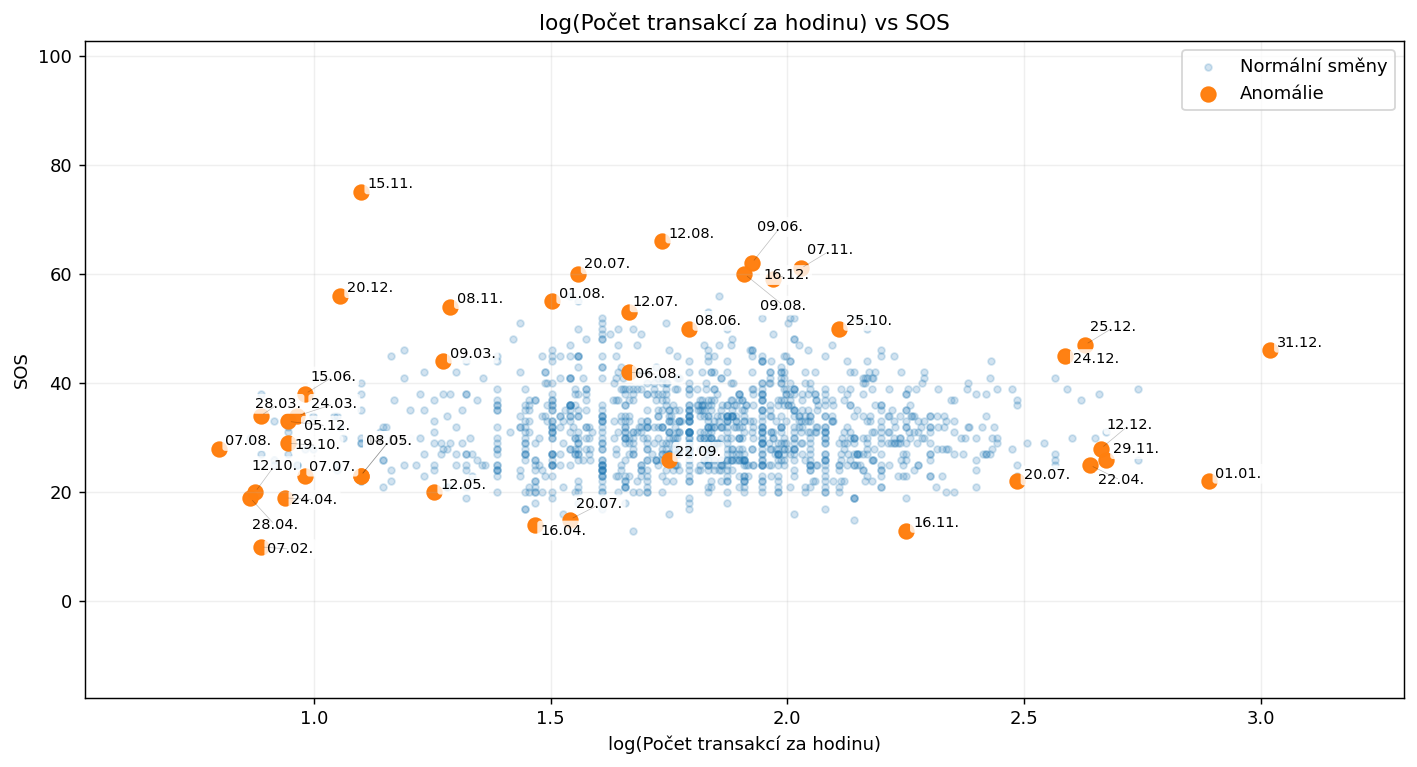

✔ uložen graf: detekce_anomalii/anom_log_trans_vs_SOS.png


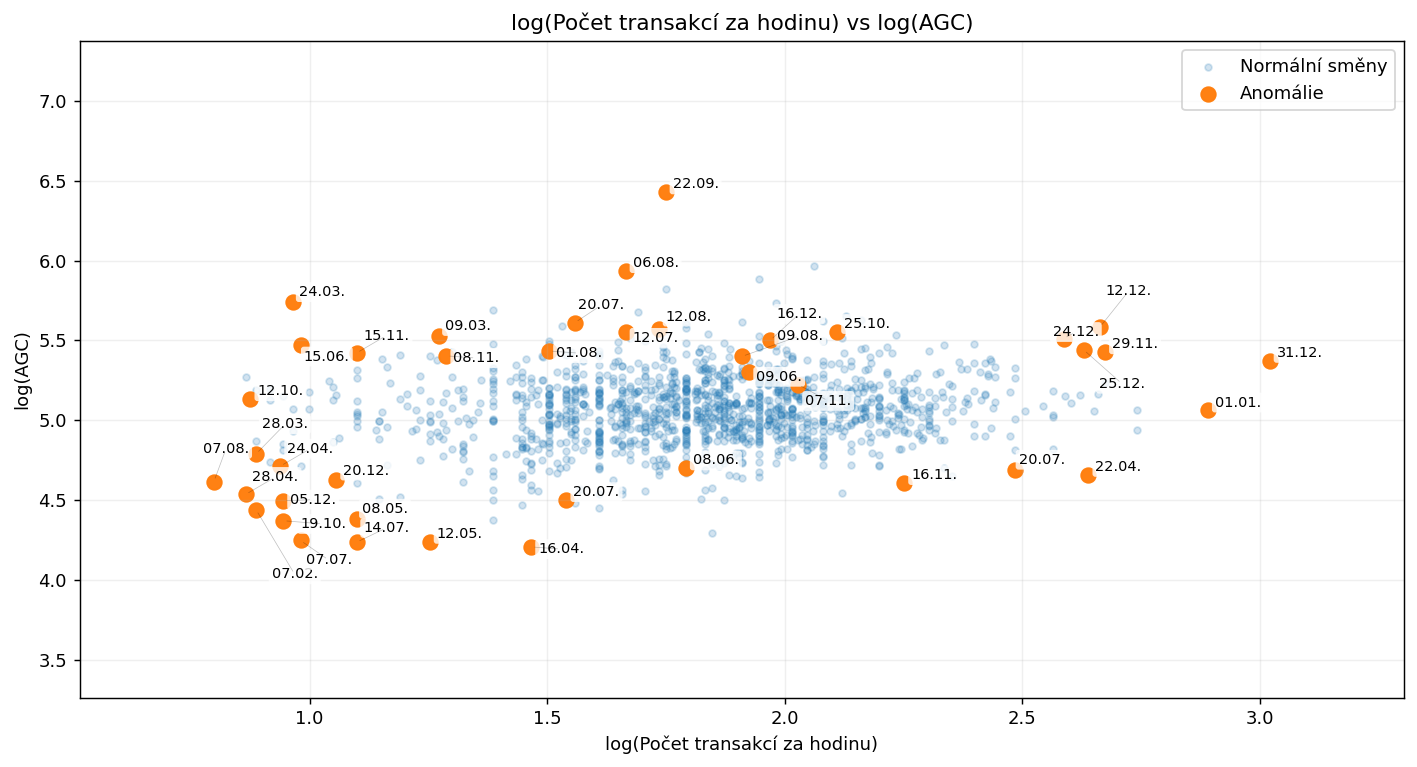

✔ uložen graf: detekce_anomalii/anom_log_trans_vs_logAGC.png


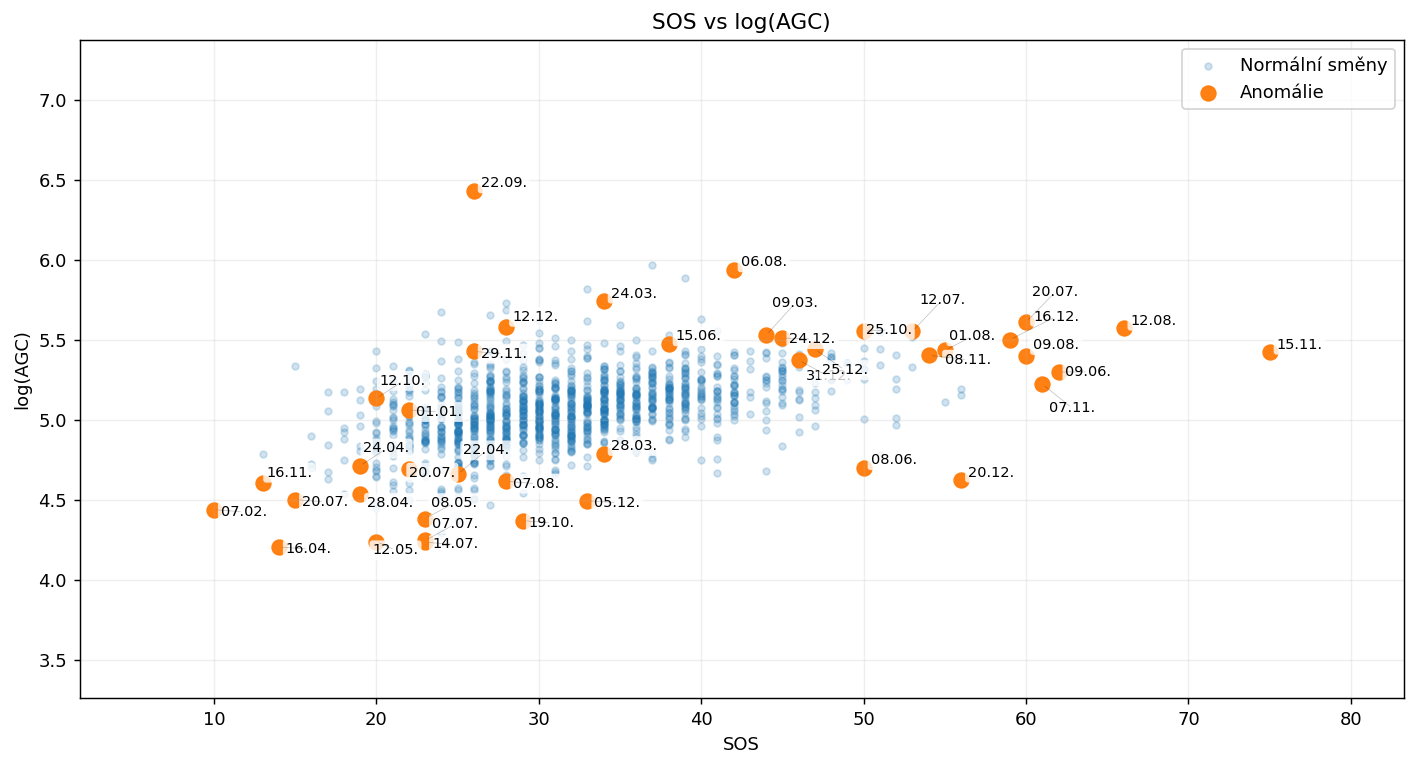

✔ uložen graf: detekce_anomalii/anom_SOS_vs_logAGC.png


,datum,ID,zamestnanec,transakce_za_hod,SOS_sec,AGC,anomalie,skore,duvod
143,2025-02-07,467,#9,1.428571,10.0,83.74,True,-0.119483,"log_agc, log_transakce_za_hod"
1304,2025-12-20,4155,#27,1.875000,56.0,100.84,True,-0.101791,SOS_sec
1182,2025-11-15,3764,#25,2.000000,75.0,225.13,True,-0.097350,SOS_sec
409,2025-04-16,1313,#29,3.333333,14.0,66.15,True,-0.084382,log_agc
769,2025-07-20,2454,#14,3.750000,60.0,272.46,True,-0.073170,SOS_sec


,log_transakce_za_hod,SOS_sec,log_agc
count,1.342000e+03,1342.000000,1342.000000
mean,-3.687662e-02,0.074143,-0.008139
std,7.832661e-01,0.766911,0.854736
min,-2.461985e+00,-2.100000,-3.326470
25%,-5.365784e-01,-0.500000,-0.519231
50%,2.636780e-16,0.000000,0.000000
75%,4.634216e-01,0.500000,0.480769
max,2.813555e+00,4.400000,5.241195


In [4]:
DET_OUT_DIR = "detekce_anomalii"
os.makedirs(DET_OUT_DIR, exist_ok=True)

OUT_ANOMALIES_CSV  = os.path.join(DET_OUT_DIR, "anomalies_final.csv")
OUT_ANOMALIES_XLSX = os.path.join(DET_OUT_DIR, "anomalies_final.xlsx")
OUT_HUMAN_SHIFTS_ANOMS_CSV = os.path.join(DET_OUT_DIR, "human_shifts_anomalities.csv")

df = pd.read_csv(OUT_SHIFTS_HUMANS_CSV)
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")

# vstupni promenne pro model
features = ["log_transakce_za_hod", "SOS_sec", "log_agc"]

# skalovani robustcaler
scaler = RobustScaler()
X_scaled_detection = scaler.fit_transform(df[features])

# Isolation Forest
CONTAM = 0.03
iso = IsolationForest(
    n_estimators=300,
    contamination=CONTAM,
    random_state=42
)

pred = iso.fit_predict(X_scaled_detection)

# logicke oznaceni anomalie (True = anomalie)
df["anomalie"] = (pred == -1)

# skore anomalnosti
df["skore"] = iso.decision_function(X_scaled_detection)


df_scaled = pd.DataFrame(
    X_scaled_detection,
    columns=[f"{c}_scaled" for c in features],
    index=df.index
)

def iso_reason_from_scaled_row(row_scaled: pd.Series, top_n=2, threshold=2.5):

    abs_vals = row_scaled.abs().sort_values(ascending=False)

    picked = []
    for name, val in abs_vals.items():
        if val >= threshold:
            picked.append(name.replace("_scaled", ""))
        if len(picked) >= top_n:
            break

    if picked:
        return ", ".join(picked)

    # kdyz nic neprekroci threshold, vratime top 1-2 i tak
    fallback = [n.replace("_scaled", "") for n in abs_vals.head(top_n).index.tolist()]
    return ", ".join(fallback) if fallback else "kombinace_faktoru"

df["duvod"] = ""
mask_anom = df["anomalie"]

df.loc[mask_anom, "duvod"] = df_scaled.loc[mask_anom].apply(
    lambda r: iso_reason_from_scaled_row(r, top_n=2, threshold=2.5),
    axis=1
)

# finalni vystup anomalii
anomalies = df[df["anomalie"]].sort_values("skore").copy()

# export vysledku
anomalies.to_csv(OUT_ANOMALIES_CSV, index=False, encoding="utf-8")
anomalies.to_excel(OUT_ANOMALIES_XLSX, index=False)

# export CELEHO datasetu s oznacenim anomalie
df.to_csv(OUT_HUMAN_SHIFTS_ANOMS_CSV, index=False, encoding="utf-8")

print("Anomalie:", anomalies.shape, "->", OUT_ANOMALIES_CSV)
print("Excel:", OUT_ANOMALIES_XLSX)
print("Cely dataset:", OUT_HUMAN_SHIFTS_ANOMS_CSV)

# diagnostika / prehled dat

from IPython.display import display

cols = ["transakce_za_hod", "log_transakce_za_hod", "SOS_sec", "AGC"]

records = []
for c in cols:
    idx_min = df[c].idxmin()
    idx_max = df[c].idxmax()

    records.append({
        "Atribut": c,

        "Minimum": df.loc[idx_min, c],
        "Min_datum": df.loc[idx_min, "datum"],
        "Min_zamestnanec": df.loc[idx_min, "zamestnanec"],

        "Maximum": df.loc[idx_max, c],
        "Max_datum": df.loc[idx_max, "datum"],
        "Max_zamestnanec": df.loc[idx_max, "zamestnanec"],
    })

df_scaled_view = pd.DataFrame(X_scaled_detection, columns=features)
df_scaled_view.describe()

# nahled TOP 20 anomalii
anomalies.head(6)
cols_preview = [
    "datum",
    "ID",
    "zamestnanec",
    "SOS_sec",
    "log_agc",
    "log_transakce_za_hod",
    "anomalie",
    "skore",
    "duvod"
]

display(df[cols_preview].head(6))

df_reason_explain = pd.concat(
    [df[["duvod"]], df_scaled],
    axis=1
).loc[mask_anom, [
    "duvod",
    "log_transakce_za_hod_scaled",
    "SOS_sec_scaled",
    "log_agc_scaled",
]]

display(df_reason_explain)

# Scatter anomáliíí
import pandas as pd
import matplotlib.pyplot as plt
import os

from adjustText import adjust_text

INPUT_FILE = OUT_HUMAN_SHIFTS_ANOMS_CSV
OUT_DIR = DET_OUT_DIR
TOP_N = 45

PAD_FRAC_X = 0.06
PAD_FRAC_Y = 0.18

MARGINS_X = 0.06
MARGINS_Y = 0.18

os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(INPUT_FILE)
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")

normal = df[df["anomalie"] == False]
anom = df[df["anomalie"] == True]
topN = anom.nsmallest(TOP_N, "skore")

def _pad_limits(ax, pad_x=0.06, pad_y=0.18):
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    xr = (xmax - xmin) if (xmax - xmin) != 0 else 1.0
    yr = (ymax - ymin) if (ymax - ymin) != 0 else 1.0

    ax.set_xlim(xmin - pad_x * xr, xmax + pad_x * xr)
    ax.set_ylim(ymin - pad_y * yr, ymax + pad_y * yr)

def plot_clean_scatter(x, y, xlabel, ylabel, filename):
    fig, ax = plt.subplots(figsize=(11, 6), dpi=130)

    # normální směny
    ax.scatter(
        normal[x], normal[y],
        s=14,
        alpha=0.20,
        label="Normální směny"
    )

    ax.scatter(
        anom[x], anom[y],
        s=65,
        alpha=0.98,
        label="Anomálie"
    )

    texts = []
    for _, r in topN.iterrows():
        if pd.isna(r["datum"]):
            continue

        label = r["datum"].strftime("%d.%m.")
        txt = ax.text(
            r[x], r[y],
            label,
            fontsize=8,
            bbox=dict(
                boxstyle="round,pad=0.20",
                fc="white",
                alpha=0.80,
                ec="none"
            )
        )
        texts.append(txt)

    ax.margins(x=MARGINS_X, y=MARGINS_Y)
    _pad_limits(ax, pad_x=PAD_FRAC_X, pad_y=PAD_FRAC_Y)

    adjust_text(
        texts,
        ax=ax,
        only_move={'points': 'y', 'text': 'y'},
        expand_points=(1.2, 1.8),
        expand_text=(1.2, 1.8),
        force_text=0.9,
        force_points=0.4,
        lim=250,
        arrowprops=dict(arrowstyle="-", lw=0.4, alpha=0.25)
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{xlabel} vs {ylabel}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.2)

    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"✔ uložen graf: {out_path}")


plot_clean_scatter(
    x="log_transakce_za_hod",
    y="SOS_sec",
    xlabel="log(Počet transakcí za hodinu)",
    ylabel="SOS",
    filename="anom_log_trans_vs_SOS.png"
)

plot_clean_scatter(
    x="log_transakce_za_hod",
    y="log_agc",
    xlabel="log(Počet transakcí za hodinu)",
    ylabel="log(AGC)",
    filename="anom_log_trans_vs_logAGC.png"
)

plot_clean_scatter(
    x="SOS_sec",
    y="log_agc",
    xlabel="SOS",
    ylabel="log(AGC)",
    filename="anom_SOS_vs_logAGC.png"
)


display(
    anomalies[
        ["datum","ID","zamestnanec","transakce_za_hod",
         "SOS_sec","AGC","anomalie","skore","duvod"]
    ].head(5)
)
df_scaled_view = pd.DataFrame(
    X_scaled_detection,
    columns=features
)

display(df_scaled_view.describe())

## Clustering

,SOS_sec,log_agc,log_transakce_za_hod
count,1342.000000,1342.000000,1342.000000
mean,0.000000,-0.000000,0.000000
std,1.000373,1.000373,1.000373
min,-2.835992,-3.883733,-3.097304
25%,-0.748923,-0.598176,-0.638210
50%,-0.096714,0.009526,0.047098
75%,0.555495,0.572212,0.638971
max,5.642726,6.143755,3.640518



Mezishlukové vzdálenosti (mezi centroidy):


/tmp/ipykernel_1353755/2402604821.py:64: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["anomalie"] = df["anomalie"].fillna(False)


,Shluk 0,Shluk 1,Shluk 2
Shluk 0,0.000,2.483,1.859
Shluk 1,2.483,0.000,1.875
Shluk 2,1.859,1.875,0.000



Průměrná vnitroshluková vzdálenost:
Shluk 0: 1.1760
Shluk 1: 1.2509
Shluk 2: 1.0501
Podíl anomálních směn v jednotlivých clusterech:


...


Profil clusterů (průměry vstupních proměnných):


,count,sos_mean,agc_mean,trans_mean,anomaly_rate
cluster,,,,,
0,378,26.767,4.881,1.528,0.037
1,389,39.941,5.251,1.743,0.051
2,575,29.464,5.066,2.064,0.012



Mezishlukové vzdálenosti:


,Shluk 0,Shluk 1,Shluk 2
Shluk 0,0.000,2.483,1.859
Shluk 1,2.483,0.000,1.875
Shluk 2,1.859,1.875,0.000


,SOS_sec,log_agc,log_transakce_za_hod
count,1342.000000,1342.000000,1342.000000
mean,0.000000,-0.000000,0.000000
std,1.000373,1.000373,1.000373
min,-2.835992,-3.883733,-3.097304
25%,-0.748923,-0.598176,-0.638210
50%,-0.096714,0.009526,0.047098
75%,0.555495,0.572212,0.638971
max,5.642726,6.143755,3.640518


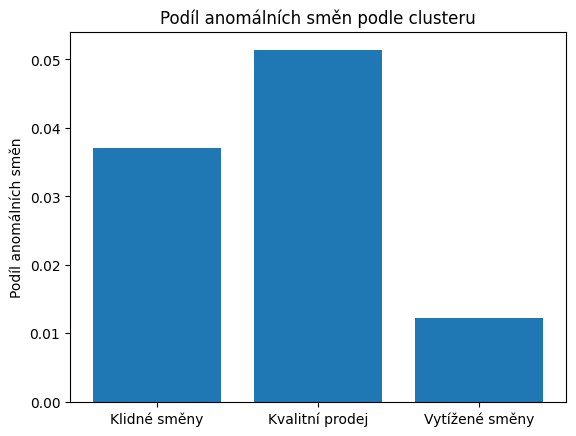

,total_shifts,anomaly_shifts,anomaly_rate
zamestnanec,,,
#6,11,3,0.272727
#27,4,1,0.250000
#22,32,5,0.156250
#11,17,2,0.117647
#25,45,5,0.111111
#2,25,2,0.080000
#12,13,1,0.076923
#10,18,1,0.055556
#15,40,2,0.050000


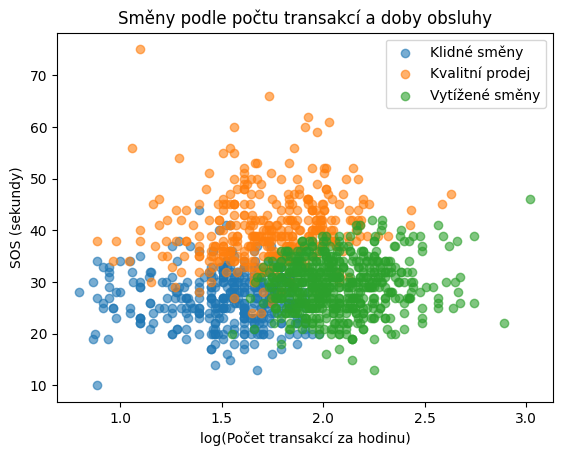

,zamestnanec,Pocet_smen,0,1,2
0,#1,32,0.094,0.281,0.625
1,#10,18,0.222,0.389,0.389
2,#11,17,0.647,0.176,0.176
3,#12,13,0.000,0.462,0.538
5,#14,72,0.097,0.472,0.431
6,#15,40,0.275,0.250,0.475
8,#17,45,0.267,0.444,0.289
11,#2,25,0.480,0.320,0.200
12,#20,101,0.129,0.406,0.465
13,#21,228,0.246,0.373,0.382


,k,silhouette
0,2,0.270
1,3,0.259
2,4,0.242
3,5,0.233
4,6,0.233
5,7,0.227
6,8,0.225


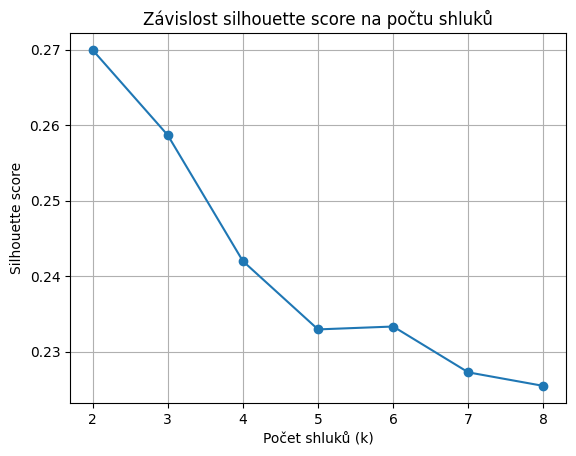

,count,sos_mean,trans_per_hour_mean,trans_log_mean,agc_mean,agc_log_mean,anomaly_rate
cluster,,,,,,,
0,378,26.767,3.747,1.528,133.038,4.881,0.037
1,389,39.941,4.912,1.743,193.195,5.251,0.051
2,575,29.464,7.071,2.064,159.416,5.066,0.012


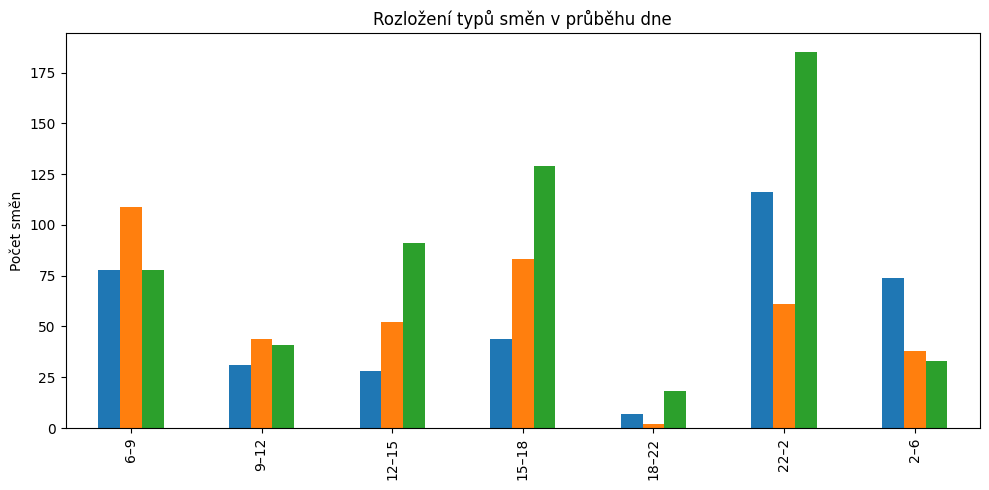

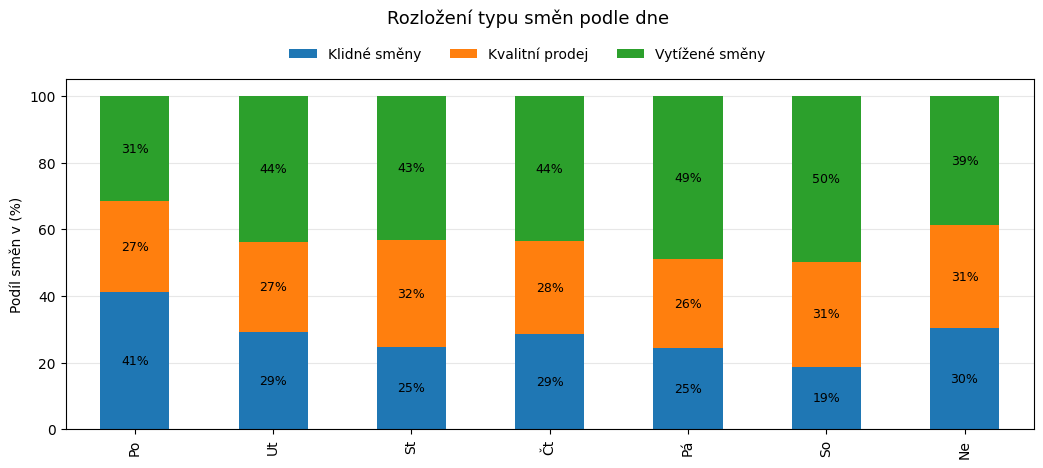

Soubor ulozen: clustering/human_shifts_clusters.csv


In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from IPython.display import display

CLUSTER_DIR = "clustering"
os.makedirs(CLUSTER_DIR, exist_ok=True)
cluster_names = {
    0: "Klidné směny",
    1: "Kvalitní prodej",
    2: "Vytížené směny"
}
df = pd.read_csv("priprava_dat/shifts_humans.csv")
df["datum"] = pd.to_datetime(df["datum"], errors="coerce")

df["dow"] = df["datum"].dt.dayofweek

# vstupni promenne k means
features = [
    "SOS_sec",             
    "log_agc",                  
    "log_transakce_za_hod",  
]

# kontrola, ze sloupce existuji
missing = [c for c in features if c not in df.columns]
if missing:
    raise ValueError(f"Chybí sloupce v datasetu: {missing}")

X = df[features].copy()

# skalovani pomoci standardScaler
scaler = StandardScaler()
X_scaled_clustering = scaler.fit_transform(X)
df_scaled_view = pd.DataFrame(
    X_scaled_clustering,
    columns=features
)

display(df_scaled_view.describe().round(6))
# KMeans
k = 3
kmeans = KMeans(n_clusters=k, n_init=30, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled_clustering)

# Pripojeni anomalii
anoms = pd.read_csv("detekce_anomalii/anomalies_final.csv")
anoms["datum"] = pd.to_datetime(anoms["datum"], errors="coerce")
need_cols = ["datum", "zamestnanec"]
missing_anoms = [c for c in need_cols if c not in anoms.columns]
if missing_anoms:
    raise ValueError(f"V anomalies_final.csv chybí sloupce: {missing_anoms}")

anoms_key = anoms[["datum", "zamestnanec"]].drop_duplicates().copy()
anoms_key["anomalie"] = True

df = df.merge(anoms_key, on=["datum", "zamestnanec"], how="left")

if "anomalie" not in df.columns:
    df["anomalie"] = False
df["anomalie"] = df["anomalie"].fillna(False)

from sklearn.metrics import pairwise_distances
import numpy as np

# centroidy (středy shluků)
centroids = kmeans.cluster_centers_

#mezishluková vzdálenost
inter_cluster_dist = pairwise_distances(centroids, metric='euclidean')

print("\nMezishlukové vzdálenosti (mezi centroidy):")
inter_df = pd.DataFrame(
    inter_cluster_dist,
    columns=[f"Shluk {i}" for i in range(k)],
    index=[f"Shluk {i}" for i in range(k)]
)
display(inter_df.round(3))


#vnitroshluková vzdálenost

intra_cluster_dist = []

for i in range(k):
    # body v daném shluku
    cluster_points = X_scaled_clustering[df["cluster"] == i]
    
    # vzdálenost od centroidu
    distances = pairwise_distances(cluster_points, [centroids[i]])
    
    # průměr
    intra_cluster_dist.append(np.mean(distances))

print("\nPrůměrná vnitroshluková vzdálenost:")
for i, dist in enumerate(intra_cluster_dist):
    print(f"Shluk {i}: {dist:.4f}")

# anomálie a clustery
print("Podíl anomálních směn v jednotlivých clusterech:")
display(df.groupby("cluster")["anomalie"].mean().round(3))

print("\nProfil clusterů (průměry vstupních proměnných):")
display(
    df.groupby("cluster").agg(
        count=("cluster", "size"),
        sos_mean=("SOS_sec", "mean"),
        agc_mean=("log_agc", "mean"),
        trans_mean=("log_transakce_za_hod", "mean"),
        anomaly_rate=("anomalie", "mean"),
    ).round(3)
)


from sklearn.metrics import pairwise_distances

# Mezishluková vzdálenost
centroids = kmeans.cluster_centers_

# výpočet vzdáleností mezi centroidy
inter_cluster_dist = pairwise_distances(centroids, metric="euclidean")

# převod do tabulky
inter_df = pd.DataFrame(
    inter_cluster_dist,
    columns=[f"Shluk {i}" for i in range(k)],
    index=[f"Shluk {i}" for i in range(k)]
)

print("\nMezishlukové vzdálenosti:")
display(inter_df.round(3))
# Kontrola skalovani
df_scaled = pd.DataFrame(X_scaled_clustering, columns=features)
display(df_scaled.describe().round(6))

# Graf: podil anomalii podle clusteru
anom_by_cluster = df.groupby("cluster")["anomalie"].mean().sort_index()

labels = [cluster_names[c] for c in anom_by_cluster.index]

plt.figure()
plt.bar(labels, anom_by_cluster.values)
plt.ylabel("Podíl anomálních směn")
plt.title("Podíl anomálních směn podle clusteru")
plt.savefig(os.path.join(CLUSTER_DIR, "anom_by_cluster.png"), dpi=300, bbox_inches="tight")
plt.show()
#  Top zamestnanci podle anomalii
anom_by_employee = (
    df.groupby("zamestnanec")["anomalie"]
      .agg(total_shifts="count", anomaly_shifts="sum", anomaly_rate="mean")
      .sort_values(["anomaly_rate", "anomaly_shifts"], ascending=False)
)
display(anom_by_employee.head(10))

# Graf: intenzita vs doba obsluhy 


plt.figure()
for c in sorted(df["cluster"].unique()):
    sub = df[df["cluster"] == c]
    plt.scatter(
        sub["log_transakce_za_hod"],
        sub["SOS_sec"],
        label=cluster_names.get(c, f"Cluster {c}"),
        alpha=0.6
    )

plt.xlabel("log(Počet transakcí za hodinu)")
plt.ylabel("SOS (sekundy)")
plt.title("Směny podle počtu transakcí a doby obsluhy")
plt.legend()
plt.savefig(os.path.join(CLUSTER_DIR, "scatter_log_transakce_za_hodinu_vs_SOS.png"), dpi=300, bbox_inches="tight")
plt.show()

# Podil clusteru podle zamestnance (jen >= 10 smen)
emp_cluster_counts = pd.pivot_table(
    df,
    index="zamestnanec",
    columns="cluster",
    values="datum",
    aggfunc="count",
    fill_value=0
)
emp_cluster_counts["Pocet_smen"] = emp_cluster_counts.sum(axis=1)

cluster_cols = [c for c in emp_cluster_counts.columns if c != "Pocet_smen"]
emp_cluster_share = (
    emp_cluster_counts[cluster_cols]
    .div(emp_cluster_counts["Pocet_smen"], axis=0)
    .round(3)
)

emp_cluster_final = pd.concat([emp_cluster_counts["Pocet_smen"], emp_cluster_share], axis=1).reset_index()
emp_cluster_final_10 = emp_cluster_final.query("Pocet_smen >= 10")
display(emp_cluster_final_10)

# Silhouette analyza (volba poctu shluku)

scores = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels_k = km.fit_predict(X_scaled_clustering)
    sil = silhouette_score(X_scaled_clustering, labels_k)
    scores.append((k, sil))

sil_df = pd.DataFrame(scores, columns=["k", "silhouette"])
display(sil_df.round(3))

plt.figure()
plt.plot(sil_df["k"], sil_df["silhouette"], marker="o")
plt.xlabel("Počet shluků (k)")
plt.ylabel("Silhouette score")
plt.title("Závislost silhouette score na počtu shluků")
plt.grid(True)
plt.savefig(os.path.join(CLUSTER_DIR, "silhouette_kmeans.png"), dpi=300, bbox_inches="tight")
plt.show()

# Profil clusteru
display(
    df.groupby("cluster").agg(
        count=("cluster", "size"),
        sos_mean=("SOS_sec", "mean"),
        trans_per_hour_mean=("transakce_za_hod", "mean"),
        trans_log_mean=("log_transakce_za_hod", "mean"),
        agc_mean=("AGC", "mean"),
        agc_log_mean=("log_agc", "mean"),
        anomaly_rate=("anomalie", "mean"),
    ).round(3)
)

# Graf: rozlozeni typu smen v case
df["smena_zacatek"] = pd.to_datetime(df["smena_zacatek"], errors="coerce")
df["hodina"] = df["smena_zacatek"].dt.hour

def usek_7(h):
    if pd.isna(h):
        return "neznamy"
    h = int(h)
    if 6 <= h < 9:
        return "6–9"
    elif 9 <= h < 12:
        return "9–12"
    elif 12 <= h < 15:
        return "12–15"
    elif 15 <= h < 18:
        return "15–18"
    elif 18 <= h < 22:
        return "18–22"
    elif h >= 22 or h < 2:
        return "22–2"
    else:
        return "2–6"

df["casovy_usek"] = df["hodina"].apply(usek_7)

poradi = ["6–9", "9–12", "12–15", "15–18", "18–22", "22–2", "2–6"]
ct = pd.crosstab(df["casovy_usek"], df["cluster"]).reindex(poradi)

ax = ct.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("Počet směn")
ax.set_title("Rozložení typů směn v průběhu dne")

# odstraneni legendy
ax.get_legend().remove()

# odstraneni nazvu osy X
ax.set_xlabel("")

plt.tight_layout()
plt.savefig(os.path.join(CLUSTER_DIR, "typ_smeny_v_case.png"), dpi=300, bbox_inches="tight")
plt.show()

# Graf: rozlozeni typu smen podle dne 

ct_share = pd.crosstab(df["dow"], df["cluster"], normalize="index") * 100
ct_share.index = ["Po", "Ut", "St", "Čt", "Pá", "So", "Ne"]

fig, ax = plt.subplots(figsize=(11, 5))

ax.set_position([0.08, 0.12, 0.88, 0.70])
ct_share.plot(kind="bar", stacked=True, ax=ax)
ax.legend_.remove()
ax.set_ylabel("Podíl směn v (%)")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)
fig.suptitle("Rozložení typu směn podle dne", y=0.96, fontsize=13)
fig.legend(
    ["Klidné směny", "Kvalitní prodej", "Vytížené směny"],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=3,
    frameon=False
)
MIN_PCT = 6
for container in ax.containers:
    for bar in container:
        h = bar.get_height()
        if h >= MIN_PCT:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                f"{h:.0f}%",
                ha="center",
                va="center",
                fontsize=9
            )

plt.savefig(
    os.path.join(CLUSTER_DIR, "typ_smeny_v_tydnu.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Export: human_shifts_clusters.csv (puvodni data + cluster + anomaly_iso)
out_path = os.path.join(CLUSTER_DIR, "human_shifts_clusters.csv")
df.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Soubor ulozen: {out_path}")

In [6]:
import pandas as pd

vypis = pd.read_csv("clustering/human_shifts_clusters.csv")

vypis[
    [
        "datum",
        "ID",
        "zamestnanec",
        "smena_zacatek",
        "smena_konec",
        "cluster",
        "anomalie",
        "dow",
        "casovy_usek",
    ]
].head()

,datum,ID,zamestnanec,smena_zacatek,smena_konec,cluster,anomalie,dow,casovy_usek
0,2025-01-01,2,#1,2025-01-01 15:00:00,2025-01-01 22:00:00,2,False,2,15–18
1,2025-01-01,6,#7,2025-01-01 22:00:00,2025-01-02 00:00:00,2,True,2,22–2
2,2025-01-01,3,#21,2025-01-01 08:00:00,2025-01-01 15:00:00,1,False,2,6–9
3,2025-01-01,4,#23,2025-01-01 03:00:00,2025-01-01 08:00:00,2,False,2,2–6
4,2025-01-02,17,#2,2025-01-02 15:00:00,2025-01-02 22:00:00,0,False,3,15–18
